In [302]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import OneHotEncoder
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score, accuracy_score, classification_report, confusion_matrix,recall_score
import matplotlib.pyplot as plt
from sklearn.neighbors import KNeighborsClassifier



In [210]:
df = pd.read_csv("Data.csv")

In [211]:
df.head(2)

,Age,Gender,Education,Experience,Department,City,Job_Level,Performance_Score,Years_at_Company,Salary
0,22,Male,Bachelors,1.0,IT,Hyderabad,Junior,3.0,1,320000
1,25,Female,Masters,3.0,HR,Bangalore,Junior,4.0,2,420000


In [212]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                30 non-null     int64  
 1   Gender             30 non-null     object 
 2   Education          30 non-null     object 
 3   Experience         29 non-null     float64
 4   Department         30 non-null     object 
 5   City               30 non-null     object 
 6   Job_Level          30 non-null     object 
 7   Performance_Score  29 non-null     float64
 8   Years_at_Company   30 non-null     int64  
 9   Salary             30 non-null     int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 2.5+ KB


In [213]:
numerical_values = df.select_dtypes(include=['int64', 'float64'])

In [214]:
categorical_values = df.select_dtypes(exclude=['int64', 'float64'])

In [215]:
df['City'].unique()

array(['Hyderabad', 'Bangalore', 'Chennai', 'Mumbai'], dtype=object)

In [216]:
df['Education'].unique() #bachelors < masters < phd
#so we have ordinal data and we should do lable encoding.

array(['Bachelors', 'Masters', 'PhD'], dtype=object)

In [217]:
x = df['Experience'].dropna()

In [218]:
df.head()

,Age,Gender,Education,Experience,Department,City,Job_Level,Performance_Score,Years_at_Company,Salary
0,22,Male,Bachelors,1.0,IT,Hyderabad,Junior,3.0,1,320000
1,25,Female,Masters,3.0,HR,Bangalore,Junior,4.0,2,420000
2,28,Male,Bachelors,5.0,IT,Hyderabad,Mid,3.0,4,550000
3,30,Female,Masters,7.0,Finance,Chennai,Mid,4.0,6,680000
4,35,Male,PhD,10.0,IT,Bangalore,Senior,5.0,9,950000


In [219]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                30 non-null     int64  
 1   Gender             30 non-null     object 
 2   Education          30 non-null     object 
 3   Experience         29 non-null     float64
 4   Department         30 non-null     object 
 5   City               30 non-null     object 
 6   Job_Level          30 non-null     object 
 7   Performance_Score  29 non-null     float64
 8   Years_at_Company   30 non-null     int64  
 9   Salary             30 non-null     int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 2.5+ KB


In [220]:
df = df.dropna(subset=['Experience','Performance_Score'])

In [221]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28 entries, 0 to 29
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                28 non-null     int64  
 1   Gender             28 non-null     object 
 2   Education          28 non-null     object 
 3   Experience         28 non-null     float64
 4   Department         28 non-null     object 
 5   City               28 non-null     object 
 6   Job_Level          28 non-null     object 
 7   Performance_Score  28 non-null     float64
 8   Years_at_Company   28 non-null     int64  
 9   Salary             28 non-null     int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 2.4+ KB


In [222]:
df.head()

,Age,Gender,Education,Experience,Department,City,Job_Level,Performance_Score,Years_at_Company,Salary
0,22,Male,Bachelors,1.0,IT,Hyderabad,Junior,3.0,1,320000
1,25,Female,Masters,3.0,HR,Bangalore,Junior,4.0,2,420000
2,28,Male,Bachelors,5.0,IT,Hyderabad,Mid,3.0,4,550000
3,30,Female,Masters,7.0,Finance,Chennai,Mid,4.0,6,680000
4,35,Male,PhD,10.0,IT,Bangalore,Senior,5.0,9,950000


In [223]:
numerical_values
numerical_values.info()
nv = numerical_values.fillna(numerical_values.mean())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                30 non-null     int64  
 1   Experience         29 non-null     float64
 2   Performance_Score  29 non-null     float64
 3   Years_at_Company   30 non-null     int64  
 4   Salary             30 non-null     int64  
dtypes: float64(2), int64(3)
memory usage: 1.3 KB


In [224]:
cv = categorical_values.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   Gender      30 non-null     object
 1   Education   30 non-null     object
 2   Department  30 non-null     object
 3   City        30 non-null     object
 4   Job_Level   30 non-null     object
dtypes: object(5)
memory usage: 1.3+ KB


In [225]:
nv.isnull().sum()

,0
Age,0
Experience,0
Performance_Score,0
Years_at_Company,0
Salary,0


In [226]:
sorted_numeric_data = nv.astype(int)

In [227]:
sorted_numeric_data

,Age,Experience,Performance_Score,Years_at_Company,Salary
0,22,1,3,1,320000
1,25,3,4,2,420000
2,28,5,3,4,550000
3,30,7,4,6,680000
4,35,10,5,9,950000
5,26,3,3,2,400000
6,40,15,4,12,1200000
7,29,6,3,5,600000
8,32,8,4,7,720000
9,45,20,5,15,1500000


In [228]:
sorted_categoric_data = categorical_values

In [229]:
sorted_categoric_data.isnull().sum()

,0
Gender,0
Education,0
Department,0
City,0
Job_Level,0


In [230]:
df.isnull().sum()

,0
Age,0
Gender,0
Education,0
Experience,0
Department,0
City,0
Job_Level,0
Performance_Score,0
Years_at_Company,0
Salary,0


In [231]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 28 entries, 0 to 29
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                28 non-null     int64  
 1   Gender             28 non-null     object 
 2   Education          28 non-null     object 
 3   Experience         28 non-null     float64
 4   Department         28 non-null     object 
 5   City               28 non-null     object 
 6   Job_Level          28 non-null     object 
 7   Performance_Score  28 non-null     float64
 8   Years_at_Company   28 non-null     int64  
 9   Salary             28 non-null     int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 2.4+ KB


In [232]:
le = LabelEncoder()

In [233]:
scd = ['Gender','Education','Job_Level','Department','City']

In [234]:
for col in scd:
  df[col] = le.fit_transform(df[col])

In [235]:
df.head()

,Age,Gender,Education,Experience,Department,City,Job_Level,Performance_Score,Years_at_Company,Salary
0,22,1,0,1.0,2,2,0,3.0,1,320000
1,25,0,1,3.0,1,0,0,4.0,2,420000
2,28,1,0,5.0,2,2,1,3.0,4,550000
3,30,0,1,7.0,0,1,1,4.0,6,680000
4,35,1,2,10.0,2,0,2,5.0,9,950000


In [236]:
df.isnull().sum()

,0
Age,0
Gender,0
Education,0
Experience,0
Department,0
City,0
Job_Level,0
Performance_Score,0
Years_at_Company,0
Salary,0


In [237]:
df

,Age,Gender,Education,Experience,Department,City,Job_Level,Performance_Score,Years_at_Company,Salary
0,22,1,0,1.0,2,2,0,3.0,1,320000
1,25,0,1,3.0,1,0,0,4.0,2,420000
2,28,1,0,5.0,2,2,1,3.0,4,550000
3,30,0,1,7.0,0,1,1,4.0,6,680000
4,35,1,2,10.0,2,0,2,5.0,9,950000
5,26,0,0,3.0,3,2,0,3.0,2,400000
6,40,1,1,15.0,0,3,2,4.0,12,1200000
7,29,0,0,6.0,2,1,1,3.0,5,600000
8,32,1,1,8.0,1,0,1,4.0,7,720000
9,45,0,2,20.0,0,3,2,5.0,15,1500000


In [238]:
df1 = pd.read_csv("Data.csv")

In [239]:
df1.isnull().sum()

,0
Age,0
Gender,0
Education,0
Experience,1
Department,0
City,0
Job_Level,0
Performance_Score,1
Years_at_Company,0
Salary,0


In [240]:
categorical_data = ['Department','City']

In [241]:
df1[categorical_data].head()

,Department,City
0,IT,Hyderabad
1,HR,Bangalore
2,IT,Hyderabad
3,Finance,Chennai
4,IT,Bangalore


In [242]:
#one hot encoding is used on non-relational data.
#for example there is a column city in that the cities are not related to each other.

ohe = OneHotEncoder()

In [243]:
ohe.fit_transform(df1[categorical_data])

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 60 stored elements and shape (30, 8)>

In [244]:
ohe

OneHotEncoder()

In [245]:
df[['Department','City']].head()

,Department,City
0,2,2
1,1,0
2,2,2
3,0,1
4,2,0


In [246]:
df.isnull().sum()

,0
Age,0
Gender,0
Education,0
Experience,0
Department,0
City,0
Job_Level,0
Performance_Score,0
Years_at_Company,0
Salary,0


In [247]:
df.shape

(28, 10)

In [248]:
new_df = df[['Department','Job_Level','City','Experience','Department','Salary','Performance_Score','Years_at_Company']]

In [249]:
new_df.head()

,Department,Job_Level,City,Experience,Department,Salary,Performance_Score,Years_at_Company
0,2,0,2,1.0,2,320000,3.0,1
1,1,0,0,3.0,1,420000,4.0,2
2,2,1,2,5.0,2,550000,3.0,4
3,0,1,1,7.0,0,680000,4.0,6
4,2,2,0,10.0,2,950000,5.0,9


In [250]:
X = new_df.drop('Salary', axis=1)
y = new_df['Salary']

In [251]:
lr = LinearRegression()


In [252]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [253]:
lr.fit(X_train, y_train)

LinearRegression()

In [254]:
y_pred = lr.predict(X_test)

In [255]:
print(y_pred)

[1552382.70575895 1606669.49743235  736108.43329064 1200053.96390746
  291909.27833897  650855.74264129]


In [256]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
rmse = np.sqrt(mse)

print("mse: ",mse)
print("r2: ",r2)
print("rmse: ",rmse)

mse:  28085488394.7217
r2:  0.911740218213642
rmse:  167587.25606298857


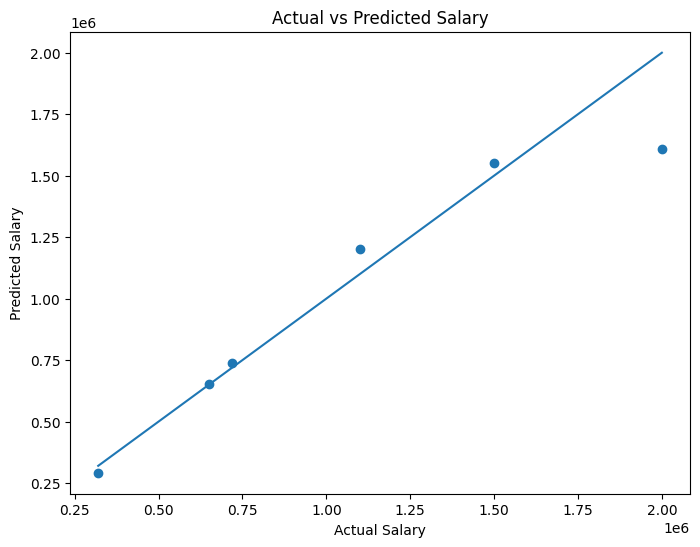

In [257]:
plt.figure(figsize=(8, 6))

plt.scatter(y_test, y_pred)

# Ideal prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()]
)

plt.xlabel("Actual Salary")
plt.ylabel("Predicted Salary")
plt.title("Actual vs Predicted Salary")

plt.show()

In [258]:
#seeing what is the error.That is how our model predicts.

error = y_test - y_pred
new = pd.DataFrame({'Actual': y_test, 'Predicted': y_pred, 'Error': error})
new.head()

,Actual,Predicted,Error
9,1500000,1.552383e+06,-52382.705759
27,2000000,1.606669e+06,393330.502568
8,720000,7.361084e+05,-16108.433291
22,1100000,1.200054e+06,-100053.963907
0,320000,2.919093e+05,28090.721661


**K-Nearest Classifier**

In [259]:
df = pd.read_csv("Placements.csv")

In [260]:
df.head()

,Student_ID,Gender,Age,Branch,CGPA,Attendance,Backlogs,Internships,Projects,Aptitude_Score,Communication_Score,Placed
0,1,Male,21,CSE,8.7,92,0,2,3,86,88,Yes
1,2,Female,21,ECE,7.2,78,1,1,2,68,72,No
2,3,Male,22,EEE,6.8,75,2,0,1,61,65,No
3,4,Female,21,CSE,8.4,89,0,2,3,82,85,Yes
4,5,Male,22,MECH,7.5,82,1,1,2,72,70,No


In [261]:
df = df.drop(columns=['Student_ID'])

In [262]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Gender               200 non-null    object 
 1   Age                  200 non-null    int64  
 2   Branch               200 non-null    object 
 3   CGPA                 200 non-null    float64
 4   Attendance           200 non-null    int64  
 5   Backlogs             200 non-null    int64  
 6   Internships          200 non-null    int64  
 7   Projects             200 non-null    int64  
 8   Aptitude_Score       200 non-null    int64  
 9   Communication_Score  200 non-null    int64  
 10  Placed               200 non-null    object 
dtypes: float64(1), int64(7), object(3)
memory usage: 17.3+ KB


In [263]:
num_X = df.select_dtypes(include=['int64','float64'])

In [264]:
num_X.head()

,Age,CGPA,Attendance,Backlogs,Internships,Projects,Aptitude_Score,Communication_Score
0,21,8.7,92,0,2,3,86,88
1,21,7.2,78,1,1,2,68,72
2,22,6.8,75,2,0,1,61,65
3,21,8.4,89,0,2,3,82,85
4,22,7.5,82,1,1,2,72,70


In [265]:
cat_X = df[['Gender','Branch']]

In [266]:
cat_X.head()

,Gender,Branch
0,Male,CSE
1,Female,ECE
2,Male,EEE
3,Female,CSE
4,Male,MECH


In [269]:
ss = StandardScaler()
ss.fit(num_X)
num_X_scaled = ss.transform(num_X)


In [270]:
num_X_scaled

array([[-0.71774056,  1.25967077,  1.26474345, ...,  0.74131188,
         1.20149214,  1.12879728],
       [-0.71774056, -0.58555009, -0.51033508, ..., -0.25373762,
        -0.38405467, -0.37188876],
       [ 1.39326109, -1.07760898, -0.89070905, ..., -1.24878713,
        -1.00065621, -1.0284389 ],
       ...,
       [ 1.39326109,  0.8906266 ,  0.88436948, ...,  1.73636139,
         0.8491484 ,  0.94121152],
       [-0.71774056,  0.02952353,  0.25041286, ..., -0.25373762,
         0.056375  ,  0.09707563],
       [-0.71774056, -1.32363843, -1.52466566, ..., -1.24878713,
        -1.44108588, -1.40361041]])

In [288]:
X = df['CGPA']

In [289]:
y = df['Placed']

In [297]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

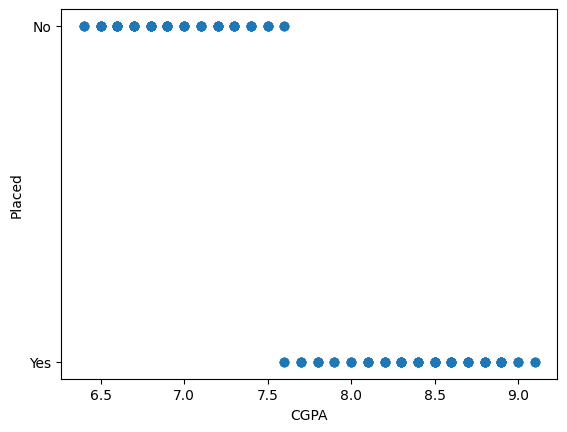

In [293]:
plt.scatter(X,y)
plt.xlabel('CGPA')
plt.ylabel('Placed')
plt.show()

In [294]:
knn = KNeighborsClassifier(n_neighbors=3)

In [298]:
knn.fit(X_train.values.reshape(-1, 1), y_train)

KNeighborsClassifier(n_neighbors=3)

In [300]:
y_pred=knn.predict(X_test.values.reshape(-1, 1))

In [311]:
y_pred

array(['No', 'Yes', 'No', 'Yes', 'No', 'No', 'No', 'Yes', 'Yes', 'No',
       'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes',
       'Yes', 'No', 'Yes', 'No', 'No', 'Yes', 'Yes', 'Yes', 'No', 'Yes',
       'No', 'No', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'Yes', 'Yes',
       'No', 'Yes', 'Yes', 'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'No',
       'Yes', 'No', 'Yes', 'No', 'Yes', 'No', 'Yes', 'Yes', 'Yes', 'No'],
      dtype=object)

In [303]:
acc = accuracy_score(y_test, y_pred)

In [304]:
acc #here our accuracy is 96%

0.9666666666666667

In [305]:
class_report = classification_report(y_test, y_pred)

In [306]:
class_report

'              precision    recall  f1-score   support\n\n          No       0.93      1.00      0.96        26\n         Yes       1.00      0.94      0.97        34\n\n    accuracy                           0.97        60\n   macro avg       0.96      0.97      0.97        60\nweighted avg       0.97      0.97      0.97        60\n'

In [309]:
cm = pd.DataFrame(confusion_matrix(y_test, y_pred), columns=['True', 'False'], index=['True', 'False'])

In [310]:
cm

,True,False
True,26,0
False,2,32


In [312]:
df.head(2)

,Age,CGPA,Attendance,Backlogs,Internships,Projects,Aptitude_Score,Communication_Score,Placed,Gender_Female,Gender_Male,Branch_CIVIL,Branch_CSE,Branch_ECE,Branch_EEE,Branch_IT,Branch_MECH
0,21,8.7,92,0,2,3,86,88,Yes,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0
1,21,7.2,78,1,1,2,68,72,No,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0


In [316]:
new_df = df.drop(columns=['Gender_Female','Gender_Male','Branch_CIVIL',	'Branch_CSE',	'Branch_ECE',	'Branch_EEE',	'Branch_IT',	'Branch_MECH'],axis=1)

In [320]:
new_df.shape

(200, 9)

In [323]:

ks = range(1,21)
scores = []

for k in ks:
  knn = KNeighborsClassifier(n_neighbors=k)
  knn.fit(X_train.values.reshape(-1, 1), y_train)
  y_pred = knn.predict(X_test.values.reshape(-1, 1))
  scores.append(y_pred)

best_k = ks[int(np.argmax(scores))]
acc = accuracy_score(y_test, y_pred)
print(acc)


0.9666666666666667


In [324]:
print(best_k)

2


In [325]:
X_train.shape

(140,)

In [326]:
y_train.shape

(140,)